<a href="https://colab.research.google.com/github/CiaraFarrellSETU/phd/blob/main/Turlough_DRY_WeatherINC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
file_path = '/content/Glenamaddy-2021-01-01-2026-05-28.csv'

try:
    # 1. Read and clean raw data structure
    df = pd.read_csv(file_path)
    df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')
    df = df.dropna(subset=['Date/Time']).set_index('Date/Time').sort_index()

    # 2. Extract water level column
    stage_col = [col for col in df.columns if 'Stage' in col][0]

    # 3. Handle Telemetry Gaps
    nan_count = df[stage_col].isna().sum()
    df[stage_col] = df[stage_col].interpolate(method='time').bfill().ffill()

    # 4. Set up physical boundaries
    historical_min = df[stage_col].min()
    historical_max = df[stage_col].max()
    dry_threshold = historical_min + 0.05  # Floor + 5cm safety buffer

    print(f" Glenamaddy data successfully processed!")
    print(f"    Repaired NaNs: {nan_count}")
    print(f"    Basin Floor:   {historical_min:.2f} mAOD")
    print(f"    Latest Level:  {df[stage_col].iloc[-1]:.2f} mAOD")

except Exception as e:
    print(f" Error loading file: {e}")

 Glenamaddy data successfully processed!
    Repaired NaNs: 1650
    Basin Floor:   75.28 mAOD
    Latest Level:  77.78 mAOD


In [7]:
LATITUDE = 53.60
LONGITUDE = -8.56
forecast_days = 16
hours_to_forecast = 24 * forecast_days

print(" Fetching live weather feed from Open-Meteo API...")
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": LATITUDE, "longitude": LONGITUDE,
    "hourly": "precipitation", "forecast_days": forecast_days,
    "timezone": "Europe/Dublin"
}

try:
    response = requests.get(url, params=params)
    raw_rain = response.json()['hourly']['precipitation']

    # CRITICAL FIX: Convert None elements to 0.0 before converting to a numpy array
    clean_rain = [0.0 if x is None else float(x) for x in raw_rain]
    live_rain_forecast = np.array(clean_rain)

    print(f"✓ Forecast loaded! Total expected rain: {live_rain_forecast.sum():.1f} mm\n")
except Exception as e:
    print(f" API parsing failed ({e}). Defaulting to dry weather projection.")
    live_rain_forecast = np.zeros(hours_to_forecast)

🌐 Fetching live weather feed from Open-Meteo API...
✓ Forecast loaded! Total expected rain: 54.8 mm



In [8]:
df['dh'] = df[stage_col].diff()
draining_phases = df[df['dh'] < -0.002].copy()
draining_phases['stage_bin'] = draining_phases[stage_col].round(2)
recession_profile = draining_phases.groupby('stage_bin')['dh'].median()

# Reindex lookup grid to eliminate gaps
full_range = np.arange(historical_min, historical_max + 0.01, 0.01)
recession_profile = recession_profile.reindex(full_range).interpolate(method='linear').bfill().ffill()

# Set up simulation starting variables
current_level = df[stage_col].iloc[-1]
starting_level = current_level
predicted_levels = [current_level]
dry_hour = None

# Run simulation step-by-step
for hour in range(hours_to_forecast):
    # Lookup natural drainage speed
    nearest_idx_loc = recession_profile.index.get_indexer([current_level], method='nearest')[0]
    natural_drop = recession_profile.iloc[nearest_idx_loc]

    # Catchment Runoff calculation (8x multiplier)
    rain_input = (live_rain_forecast[hour] / 1000.0) * 8.0

    # Advance system
    next_level = current_level + natural_drop + rain_input

    # Floor checks
    if next_level <= dry_threshold:
        next_level = historical_min
        if dry_hour is None:
            dry_hour = hour
    else:
        if dry_hour is not None and next_level > dry_threshold:
            dry_hour = None  # Reset if re-flooded by a downpour

    next_level = max(min(next_level, historical_max), historical_min)
    predicted_levels.append(next_level)
    current_level = next_level

             GLENAMADDY FORECAST DASHBOARD             
Starting Level: 77.78 mAOD
Basin Floor:    75.28 mAOD

☀️ STATUS: DRY-OUT ESTIMATED
👉 The turlough goes dry in 283 hours (11.8 days).



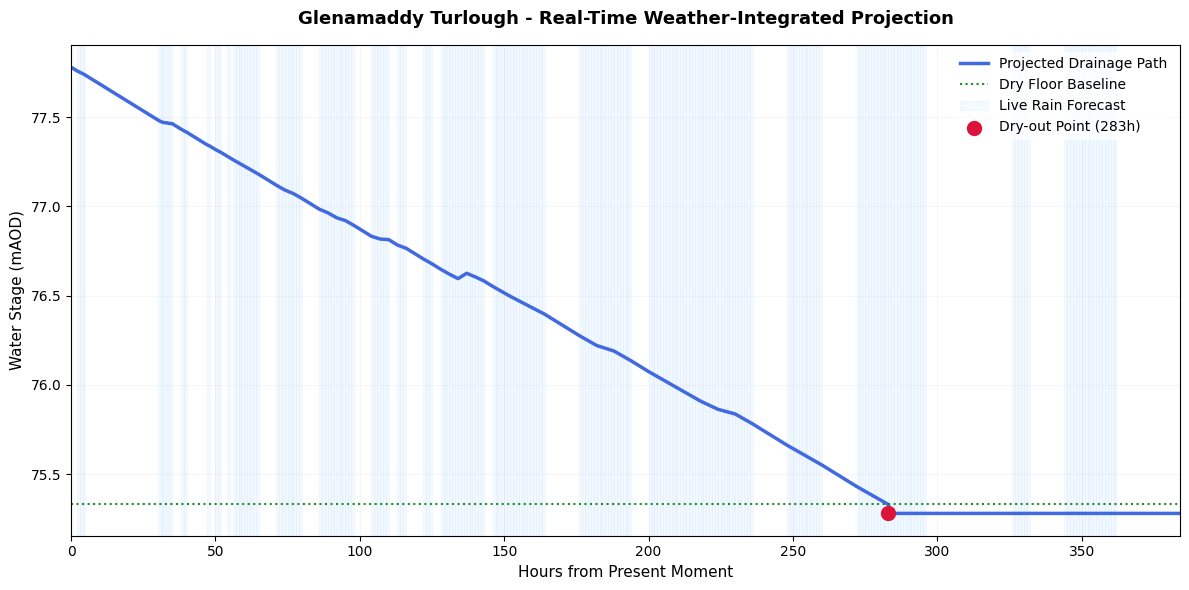

In [9]:
print("="*50)
print("             GLENAMADDY FORECAST DASHBOARD             ")
print("="*50)
print(f"Starting Level: {starting_level:.2f} mAOD")
print(f"Basin Floor:    {historical_min:.2f} mAOD")

if dry_hour is not None:
    days = dry_hour / 24
    print(f"\n☀️ STATUS: DRY-OUT ESTIMATED")
    print(f"👉 The turlough goes dry in {dry_hour} hours ({days:.1f} days).")
else:
    print(f"\n🌧️ STATUS: FLOODED")
    print(f"👉 Water remains above baseline for the next 16 days.")
print("="*50 + "\n")

# Generate the plot
plt.figure(figsize=(12, 6))
plt.plot(predicted_levels, label='Projected Drainage Path', color='royalblue', linewidth=2.5)
plt.axhline(y=dry_threshold, color='forestgreen', linestyle=':', label='Dry Floor Baseline')

# Shade live rain periods
rain_hours = np.where(live_rain_forecast > 0.0)[0]
for r_hour in rain_hours:
    plt.axvspan(r_hour, r_hour+1, color='#bde0fe', alpha=0.15, label='Live Rain Forecast' if r_hour == rain_hours[0] else "")

if dry_hour is not None:
    plt.scatter(dry_hour, historical_min, color='crimson', s=100, zorder=5, label=f'Dry-out Point ({int(dry_hour)}h)')

plt.title('Glenamaddy Turlough - Real-Time Weather-Integrated Projection', fontsize=13, weight='bold', pad=15)
plt.xlabel('Hours from Present Moment', fontsize=11)
plt.ylabel('Water Stage (mAOD)', fontsize=11)
plt.grid(True, linestyle='-', alpha=0.1)
plt.xlim(0, hours_to_forecast)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
raw_folder = '/content/turloughs/'
clean_folder = '/content/turloughs_clean/'

# Create the clean output directory if it doesn't exist
os.makedirs(clean_folder, exist_ok=True)

# Find all messy CSVs in the raw folder
csv_files = glob.glob(os.path.join(raw_folder, "*.csv"))

if len(csv_files) == 0:
    print(f"❌ No files found in {raw_folder}. Pointing to default fallback path...")
    csv_files = ['/content/Glenamaddy-2021-01-01-2026-04-23.csv']

print(f"🧼 Found {len(csv_files)} file(s) to process. Starting pipeline...\n")

for file_path in csv_files:
    file_name = os.path.basename(file_path)
    # Extract clean name (e.g., "Glenamaddy")
    site_name = file_name.split('-')[0].split('.')[0]

    try:
        # Load messy file
        df = pd.read_csv(file_path)

        # Format timestamps and drop invalid entries
        df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')
        df = df.dropna(subset=['Date/Time']).set_index('Date/Time').sort_index()

        # Dynamically locate Stage/Water level column
        stage_col = [col for col in df.columns if 'Stage' in col]
        if not stage_col:
            print(f"⚠️ Skipping {site_name}: Water level 'Stage' column missing.")
            continue
        stage_col = stage_col[0]

        # Handle Missing Telemetry NaNs
        nan_count = df[stage_col].isna().sum()
        if nan_count > 0:
            df[stage_col] = df[stage_col].interpolate(method='time') # Time-weighted blend
            df[stage_col] = df[stage_col].bfill().ffill()             # Edge safety fill
            print(f"   ↳ {site_name}: Successfully repaired {nan_count} missing readings.")
        else:
            print(f"   ↳ {site_name}: 100% clean record found.")

        # Export standardized file
        output_path = os.path.join(clean_folder, f"{site_name}_clean.csv")
        df.reset_index().to_csv(output_path, index=False)

    except Exception as e:
        print(f"❌ Crash on site '{site_name}': {e}")

print(f"\n🎉 DATA REPAIR COMPLETE. Standardized files exported to: {clean_folder}")

🧼 Found 4 file(s) to process. Starting pipeline...

   ↳ Fortwilliam Turlough: Successfully repaired 7136 missing readings.
   ↳ Glenamaddy: Successfully repaired 1650 missing readings.
   ↳ Tulla Turlough: Successfully repaired 4489 missing readings.
   ↳ Ballygalda Turlough: Successfully repaired 27 missing readings.

🎉 DATA REPAIR COMPLETE. Standardized files exported to: /content/turloughs_clean/


In [13]:
site_registry = {
    "Glenamaddy":  {"lat": 53.60, "lon": -8.56, "multiplier": 8.0},
    "Fortwilliam": {"lat": 53.62, "lon": -7.98, "multiplier": 10.0},
    "Tulla":       {"lat": 53.07, "lon": -8.95, "multiplier": 7.0},
    "Ballygalda":  {"lat": 53.60, "lon": -8.23, "multiplier": 12.0}
}

clean_folder = '/content/turloughs_clean/'
forecast_days = 16
hours_to_forecast = 24 * forecast_days

# Locate cleaned files from your pipeline
csv_files = glob.glob(os.path.join(clean_folder, "*_clean.csv"))

if len(csv_files) == 0:
    print(f"❌ No files found in '{clean_folder}'. Make sure you ran your data cleaning cell first.")
else:
    # Set up dashboard visuals
    plt.figure(figsize=(14, 7))
    colors = ['#4361ee', '#2a9d8f', '#7209b7', '#f72585', '#4cc9f0', '#e76f51']

    print("=====================================================================")
    print("     LAUNCHING LIVE INTER-REGIONAL WEATHER-COUPLED SIMULATOR        ")
    print("=====================================================================\n")

     LAUNCHING LIVE INTER-REGIONAL WEATHER-COUPLED SIMULATOR        



<Figure size 1400x700 with 0 Axes>

☀️ Fortwilliam Turlough | Current:  42.23 mAOD | Est. Dry-out:   0.6 Days (15 hrs)
☀️ Ballygalda Turlough | Current:  48.54 mAOD | Est. Dry-out:   5.8 Days (138 hrs)
☀️ Tulla Turlough  | Current:  10.54 mAOD | Est. Dry-out:   3.1 Days (75 hrs)
☀️ Glenamaddy      | Current:  77.78 mAOD | Est. Dry-out:  11.7 Days (281 hrs)


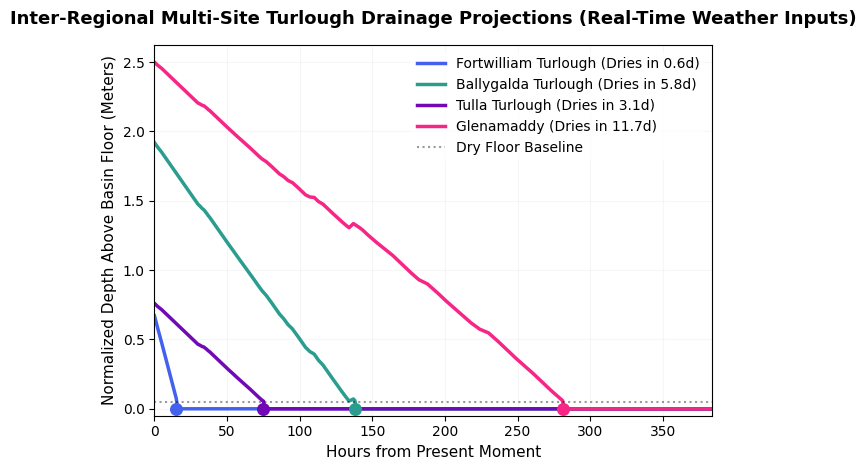

In [19]:
for idx, file_path in enumerate(csv_files):
        # Match clean file name to dictionary registry keys
        site_name = os.path.basename(file_path).replace('_clean.csv', '')
        color = colors[idx % len(colors)]

        # Pull localized geography metrics or default to standard fallback values
        lat = site_registry.get(site_name, {"lat": 53.60})["lat"]
        lon = site_registry.get(site_name, {"lon": -8.56})["lon"]
        mult = site_registry.get(site_name, {"multiplier": 8.0})["multiplier"]

        # Fetch hyper-local weather forecast matrix from API
        url = "https://api.open-meteo.com/v1/forecast"
        params = {"latitude": lat, "longitude": lon, "hourly": "precipitation",
                  "forecast_days": forecast_days, "timezone": "Europe/Dublin"}

        try:
            response = requests.get(url, params=params)
            raw_rain = response.json()['hourly']['precipitation']
            # Clean array to eliminate NoneType bugs
            live_rain_forecast = np.array([0.0 if x is None else float(x) for x in raw_rain])
        except Exception as e:
            print(f"⚠️ Weather API failed for {site_name} ({e}). Defaulting to dry curve baseline.")
            live_rain_forecast = np.zeros(hours_to_forecast)

        # Load cleaned historical dataframe
        df = pd.read_csv(file_path, parse_dates=['Date/Time']).set_index('Date/Time')
        stage_col = [col for col in df.columns if 'Stage' in col][0]

        historical_min = df[stage_col].min()
        historical_max = df[stage_col].max()
        dry_threshold = historical_min + 0.05

        # Calculate historical drainage speed characteristics
        df['dh'] = df[stage_col].diff()
        draining_phases = df[df['dh'] < -0.002].copy()
        draining_phases['stage_bin'] = draining_phases[stage_col].round(2)
        recession_profile = draining_phases.groupby('stage_bin')['dh'].median()

        # Interpolate profile index table to secure zero gap coverage
        full_range = np.arange(historical_min, historical_max + 0.01, 0.01)
        recession_profile = recession_profile.reindex(full_range).interpolate(method='linear').bfill().ffill()

        # Initialize loop configuration variables
        current_level = df[stage_col].iloc[-1]
        starting_level = current_level
        predicted_depths = [current_level - historical_min] # Normalized water column depth
        dry_hour = None

        # Main projection loop
        for hour in range(hours_to_forecast):
            # Find nearest historical coordinate match for drainage tracking
            nearest_idx_loc = recession_profile.index.get_indexer([current_level], method='nearest')[0]
            natural_drop = recession_profile.iloc[nearest_idx_loc]

            # Apply site-specific rain catchment runoff transformation
            rain_input = (live_rain_forecast[hour] / 1000.0) * mult

            next_level = current_level + natural_drop + rain_input

            # Floor limits adjustments
            if next_level <= dry_threshold:
                next_level = historical_min
                if dry_hour is None:
                    dry_hour = hour
            else:
                if dry_hour is not None and next_level > dry_threshold:
                    dry_hour = None # Reset dry execution mark if rain refills it

            next_level = max(min(next_level, historical_max), historical_min)
            predicted_depths.append(next_level - historical_min)
            current_level = next_level

        # Display operational diagnostics
        if dry_hour is not None:
            days = dry_hour / 24
            print(f"☀️ {site_name:15} | Current: {starting_level:6.2f} mAOD | Est. Dry-out: {days:5.1f} Days ({dry_hour} hrs)")
            plot_label = f"{site_name} (Dries in {days:.1f}d)"
        else:
            print(f"🌧️ {site_name:15} | Current: {starting_level:6.2f} mAOD | Remaining Flooded > 16 Days")
            plot_label = f"{site_name} (Stays flooded)"

        # Plot regional relative line profiles
        plt.plot(predicted_depths, label=plot_label, color=color, linewidth=2.5)
        if dry_hour is not None:
            plt.scatter(dry_hour, 0, color=color, s=70, zorder=5)

plt.axhline(y=0.05, color='black', linestyle=':', alpha=0.4, label='Dry Floor Baseline')
plt.title('Inter-Regional Multi-Site Turlough Drainage Projections (Real-Time Weather Inputs)', fontsize=13, weight='bold', pad=15)
plt.xlabel('Hours from Present Moment', fontsize=11)
plt.ylabel('Normalized Depth Above Basin Floor (Meters)', fontsize=11)
plt.grid(True, linestyle='-', alpha=0.1)
plt.xlim(0, hours_to_forecast)
plt.ylim(-0.05, None)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()